# Decision Layer — Replenishment Rules & What-If Simulator

Validates `src/decision/` modules:
- `safety_stock.py`
- `replenishment_rules.py`
- `simulation/cost_impact_sim.py`
- `simulation/what_if_simulator.py`

## 1) Imports and Paths

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sys

sys.path.insert(0, str(Path('..').resolve() / 'src'))

from decision.safety_stock import safety_stock_quantile, safety_stock_mad, compute_safety_stock
from decision.replenishment_rules import (
    compute_reorder_quantity, should_reorder,
    compute_reorder_point, generate_replenishment_card,
)
from decision.simulation.cost_impact_sim import simulate_order_cost, compare_order_quantities
from decision.simulation.what_if_simulator import (
    simulate_scenario, simulate_batch_scenarios, generate_scenario_summary_text,
)
from xai.uncertainty import compute_sku_residual_std, compute_prediction_interval

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
MODEL_PATH = ROOT / 'artifacts' / 'models' / 'tuned_lgbm_7_v3.joblib'

model    = joblib.load(MODEL_PATH)
train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

TARGET       = 'aggregated_sales_7'
DROP_COLS    = [TARGET, 'date', 'item_id']
feature_cols = [c for c in train_df.columns if c not in DROP_COLS]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[feature_cols].copy()

train_preds = model.predict(X_train)
test_preds  = model.predict(X_test)

# Per-SKU uncertainty
sku_std    = compute_sku_residual_std(y_train, train_preds, train_df['item_id'])
global_std = float(sku_std.mean())

# Target SKU
target_sku = 'FOODS_3_090'
sku_pred   = float(test_preds[test_df['item_id'] == target_sku][0])
sku_std_v  = float(sku_std.get(target_sku, global_std))
interval   = compute_prediction_interval(sku_pred, sku_std_v)

print(f'SKU: {target_sku}')
print(f'q10: {interval["q10"]:.2f}  |  q50: {interval["q50"]:.2f}  |  q90: {interval["q90"]:.2f}')
print(f'per-SKU residual std: {sku_std_v:.2f}')

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
SKU: FOODS_3_090
q10: 197.84  |  q50: 384.37  |  q90: 570.90
per-SKU residual std: 145.73


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 2) Safety Stock — Both Methods

In [14]:
LEAD_TIME = 7   # days

# Method 1: quantile-based (uses our q50/q90 from the model's uncertainty)
ss_q = safety_stock_quantile(
    q50=interval['q50'], q90=interval['q90'], lead_time_days=LEAD_TIME
)

# Method 2: MAD-based (uses per-SKU MAD of training residuals as proxy for forecast error)
sku_mask = train_df['item_id'] == target_sku
residuals = y_train[sku_mask].values - train_preds[sku_mask]
mad       = float(np.mean(np.abs(residuals)))
ss_mad    = safety_stock_mad(mad=mad, lead_time_days=LEAD_TIME, service_level=0.95)

# Dispatcher test
ss_dispatch = compute_safety_stock(method='quantile', q50=interval['q50'],
                                    q90=interval['q90'], lead_time_days=LEAD_TIME)

print(f'Safety stock — quantile method:  {ss_q:.2f} units')
print(f'Safety stock — MAD method (95%): {ss_mad:.2f} units')
print(f'compute_safety_stock dispatcher: {ss_dispatch:.2f} units  (should match quantile)')
print(f'\nMAD of training residuals: {mad:.2f}')

Safety stock — quantile method:  186.53 units
Safety stock — MAD method (95%): 658.94 units
compute_safety_stock dispatcher: 186.53 units  (should match quantile)

MAD of training residuals: 102.13


## 3) Replenishment Rules

In [15]:
q50       = interval['q50']
ss        = ss_q
soh_vals  = [0.0, q50 * 0.5, q50, q50 * 1.5]  # stock scenarios: none / half / at / above forecast

avg_daily = q50 / 7.0
rop       = compute_reorder_point(avg_daily, LEAD_TIME, ss)

print(f'Forecast q50:      {q50:.2f} units / 7 days')
print(f'Avg daily demand:  {avg_daily:.2f} units/day')
print(f'Safety stock:      {ss:.2f} units')
print(f'Reorder point:     {rop:.2f} units')
print()
print(f'{"Stock on Hand":>15} | {"Should Reorder":>14} | {"Reorder Qty":>12}')
print('-' * 50)
for soh in soh_vals:
    trigger = should_reorder(soh, rop)
    rqty    = compute_reorder_quantity(q50, ss, soh)
    print(f'{soh:>15.2f} | {str(trigger):>14} | {rqty:>12.2f}')

Forecast q50:      384.37 units / 7 days
Avg daily demand:  54.91 units/day
Safety stock:      186.53 units
Reorder point:     570.90 units

  Stock on Hand | Should Reorder |  Reorder Qty
--------------------------------------------------
           0.00 |           True |       570.90
         192.19 |           True |       378.71
         384.37 |           True |       186.53
         576.56 |          False |         0.00


## 4) Replenishment Card

In [16]:
# Simulate a low-stock scenario to show CRITICAL urgency
card_low = generate_replenishment_card(
    sku_id        = target_sku,
    forecast      = interval,
    stock_on_hand = q50 * 0.3,   # only 30% of forecast left in stock
    lead_time_days= LEAD_TIME,
    safety_stock  = ss,
)

# Simulate a well-stocked scenario
card_ok = generate_replenishment_card(
    sku_id        = target_sku,
    forecast      = interval,
    stock_on_hand = q50 * 2.5,   # 250% of forecast in stock
    lead_time_days= LEAD_TIME,
    safety_stock  = ss,
)

print('=== LOW STOCK CARD ===')
for k, v in card_low.items():
    print(f'  {k:25s}: {v}')

print('\n=== WELL-STOCKED CARD ===')
for k, v in card_ok.items():
    print(f'  {k:25s}: {v}')

=== LOW STOCK CARD ===
  sku_id                   : FOODS_3_090
  forecast_q10             : 197.84
  forecast_q50             : 384.37
  forecast_q90             : 570.9
  safety_stock             : 186.53
  stock_on_hand            : 115.31
  lead_time_days           : 7
  days_of_stock            : 2.1
  reorder_point            : 570.9
  reorder_qty              : 455.59
  trigger_reorder          : True
  urgency                  : CRITICAL
  confidence_band_pct      : 97.1

=== WELL-STOCKED CARD ===
  sku_id                   : FOODS_3_090
  forecast_q10             : 197.84
  forecast_q50             : 384.37
  forecast_q90             : 570.9
  safety_stock             : 186.53
  stock_on_hand            : 960.92
  lead_time_days           : 7
  days_of_stock            : 17.5
  reorder_point            : 570.9
  reorder_qty              : 0.0
  trigger_reorder          : False
  urgency                  : LOW
  confidence_band_pct      : 97.1


## 5) Replenishment Cards — All Test SKUs

In [17]:
# Build replenishment cards for all SKUs in the test set
# Stock on hand simulated as 1 week of median forecast (arbitrary — no real inventory data)
cards = []
for sku in test_df['item_id'].unique():
    rows_sku  = test_df[test_df['item_id'] == sku]
    pred_sku  = float(test_preds[test_df['item_id'] == sku][0])
    std_sku   = float(sku_std.get(sku, global_std))
    iv        = compute_prediction_interval(pred_sku, std_sku)
    ss_sku    = safety_stock_quantile(iv['q50'], iv['q90'], LEAD_TIME)
    soh       = iv['q50']  # assume stock = 1 week of median forecast
    card      = generate_replenishment_card(sku, iv, soh, LEAD_TIME, ss_sku)
    cards.append(card)

cards_df = pd.DataFrame(cards)
print(f'Total SKUs: {len(cards_df)}')
print(f'\nUrgency distribution:')
print(cards_df['urgency'].value_counts())
print(f'\nSKUs that trigger reorder: {cards_df["trigger_reorder"].sum()}')
print(f'\nTop 10 by reorder qty:')
cards_df.nlargest(10, 'reorder_qty')[['sku_id','forecast_q50','reorder_qty','urgency','trigger_reorder']]

Total SKUs: 1437

Urgency distribution:
urgency
CRITICAL    1326
HIGH         108
LOW            3
Name: count, dtype: int64

SKUs that trigger reorder: 1437

Top 10 by reorder qty:


,sku_id,forecast_q50,reorder_qty,urgency,trigger_reorder
702,FOODS_3_090,384.37,186.53,CRITICAL,True
732,FOODS_3_120,334.19,85.42,CRITICAL,True
894,FOODS_3_282,207.59,75.31,CRITICAL,True
1293,FOODS_3_681,136.69,73.04,CRITICAL,True
1394,FOODS_3_785,51.40,64.77,CRITICAL,True
1113,FOODS_3_501,164.47,62.17,CRITICAL,True
814,FOODS_3_202,113.21,58.02,CRITICAL,True
907,FOODS_3_295,113.21,56.16,CRITICAL,True
1349,FOODS_3_739,109.36,50.03,CRITICAL,True
864,FOODS_3_252,212.34,48.48,CRITICAL,True


## 6) Cost-Impact Simulation (Decision Layer)

In [18]:
UNIT_MARGIN  = 3.50
HOLDING_COST = 0.80

# Cost at three order quantities: q10, q50, q90
for label, oq in [('order q10', interval['q10']), ('order q50', interval['q50']), ('order q90', interval['q90'])]:
    costs = simulate_order_cost(
        q10=interval['q10'], q50=interval['q50'], q90=interval['q90'],
        order_qty=oq,
        unit_margin=UNIT_MARGIN,
        holding_cost_per_unit=HOLDING_COST,
    )
    print(f'{label} ({oq:.1f} units):')
    for k, v in costs.items():
        print(f'  {k}: ${v:.2f}')
    print()

order q10 (197.8 units):
  mean_stockout_cost: $774.68
  mean_overstock_cost: $1.39
  mean_total_cost: $776.07
  p5_total_cost: $29.77
  p95_total_cost: $1963.11

order q50 (384.4 units):
  mean_stockout_cost: $292.75
  mean_overstock_cost: $40.46
  mean_total_cost: $333.20
  p5_total_cost: $11.43
  p95_total_cost: $1310.26

order q90 (570.9 units):
  mean_stockout_cost: $92.71
  mean_overstock_cost: $143.96
  mean_total_cost: $236.66
  p5_total_cost: $30.94
  p95_total_cost: $657.40



In [19]:
# Compare 6 order quantities side-by-side
candidates = np.linspace(interval['q10'] * 0.8, interval['q90'] * 1.2, 6).tolist()
comparison = compare_order_quantities(
    q10=interval['q10'], q50=interval['q50'], q90=interval['q90'],
    quantities=candidates,
    unit_margin=UNIT_MARGIN,
    holding_cost_per_unit=HOLDING_COST,
)
print('Order quantity cost comparison (sorted by mean_total_cost):')
comparison

Order quantity cost comparison (sorted by mean_total_cost):


,order_qty,is_optimal,mean_stockout_cost,mean_overstock_cost,mean_total_cost,p5_total_cost,p95_total_cost
0,579.72,False,84.28,150.79,235.06,31.33,597.57
1,474.36,False,163.24,84.55,247.79,17.55,966.34
2,685.08,False,43.41,225.74,269.15,56.70,426.78
3,369.00,False,314.06,34.73,348.79,12.77,1335.10
4,263.63,False,563.67,7.50,571.16,13.61,1703.87
5,158.27,False,900.87,0.28,901.16,115.33,2072.63


## 7) What-If Scenario Simulator

In [20]:
# Baseline row (first test observation for target SKU)
X_sku = X_test[test_df['item_id'] == target_sku].iloc[[0]]

# Find snap and price columns that exist in the dataset
snap_cols  = [c for c in X_sku.columns if 'snap' in c.lower()]
price_cols = [c for c in X_sku.columns if 'price' in c.lower() or 'sell' in c.lower()]
print('Available SNAP columns:', snap_cols)
print('Available price columns:', price_cols[:5])

Available SNAP columns: ['snap_relevant']
Available price columns: ['aggregated_sell_price', 'price_lag_1', 'price_change_bucket']


In [21]:
STOCK_ON_HAND = float(interval['q50'])  # assume current stock = 1 week forecast

# Scenario: SNAP benefit ON (if SNAP col exists) or price reduction
snap_col  = snap_cols[0]  if snap_cols  else None
price_col = price_cols[0] if price_cols else None

overrides_snap  = {snap_col:  1} if snap_col  else {}
overrides_price = {price_col: float(X_sku[price_col].iloc[0]) * 0.9} if price_col else {}

print('=== Scenario 1: SNAP ON ===')
if overrides_snap:
    result_snap = simulate_scenario(
        model=model, X_row=X_sku, overrides=overrides_snap,
        stock_on_hand=STOCK_ON_HAND, lead_time_days=LEAD_TIME,
        residual_std=sku_std_v, unit_margin=UNIT_MARGIN, holding_cost=HOLDING_COST,
    )
    print(f'  Baseline: {result_snap["baseline_pred"]:.2f} → Scenario: {result_snap["scenario_pred"]:.2f}  (Δ {result_snap["delta"]:+.2f} units, {result_snap["delta_pct"]:+.1f}%)')
    print(f'  Reorder qty: {result_snap["reorder_qty"]:.2f} | Safety stock: {result_snap["safety_stock"]:.2f}')
else:
    print('  No SNAP column found — skipping')

print('\n=== Scenario 2: Price −10% ===')
if overrides_price:
    result_price = simulate_scenario(
        model=model, X_row=X_sku, overrides=overrides_price,
        stock_on_hand=STOCK_ON_HAND, lead_time_days=LEAD_TIME,
        residual_std=sku_std_v, unit_margin=UNIT_MARGIN, holding_cost=HOLDING_COST,
    )
    print(f'  Baseline: {result_price["baseline_pred"]:.2f} → Scenario: {result_price["scenario_pred"]:.2f}  (Δ {result_price["delta"]:+.2f} units, {result_price["delta_pct"]:+.1f}%)')
    print(f'  Reorder qty: {result_price["reorder_qty"]:.2f} | Safety stock: {result_price["safety_stock"]:.2f}')
else:
    print('  No price column found — skipping')

=== Scenario 1: SNAP ON ===
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
  Baseline: 384.37 → Scenario: 392.14  (Δ +7.77 units, +2.0%)
  Reorder qty: 194.30 | Safety stock: 186.53

=== Scenario 2: Price −10% ===
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 8) Batch Scenario Comparison

In [22]:
scenarios = [
    {'label': 'Baseline (no change)'},
]
if snap_col:
    scenarios += [
        {'label': 'SNAP ON',  **{snap_col: 1}},
        {'label': 'SNAP OFF', **{snap_col: 0}},
    ]
if price_col:
    base_price = float(X_sku[price_col].iloc[0])
    scenarios += [
        {'label': 'Price −10%', **{price_col: base_price * 0.90}},
        {'label': 'Price +10%', **{price_col: base_price * 1.10}},
        {'label': 'Price −20%', **{price_col: base_price * 0.80}},
    ]

batch_df = simulate_batch_scenarios(
    model=model, X_row=X_sku, scenarios=scenarios,
    stock_on_hand=STOCK_ON_HAND, lead_time_days=LEAD_TIME,
    residual_std=sku_std_v, unit_margin=UNIT_MARGIN, holding_cost=HOLDING_COST,
)
print(f'Batch scenarios for SKU: {target_sku}\n')
batch_df

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ign

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserW

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
Batch scenarios for SKU: FOODS_3_090



,label,scenario_pred,delta,delta_pct,safety_stock,reorder_qty,mean_total_cost
0,Baseline (no change),384.3701,0.0000,0.00,186.53,186.53,813.23
1,SNAP ON,392.1377,7.7676,2.02,186.53,194.30,809.91
2,SNAP OFF,384.3701,0.0000,0.00,186.53,186.53,813.23
3,Price −10%,387.4916,3.1215,0.81,186.53,189.65,811.87
4,Price +10%,376.9401,-7.4300,-1.93,186.53,179.10,816.63
5,Price −20%,386.9790,2.6089,0.68,186.53,189.14,812.09


## 9) Scenario Comparison Chart

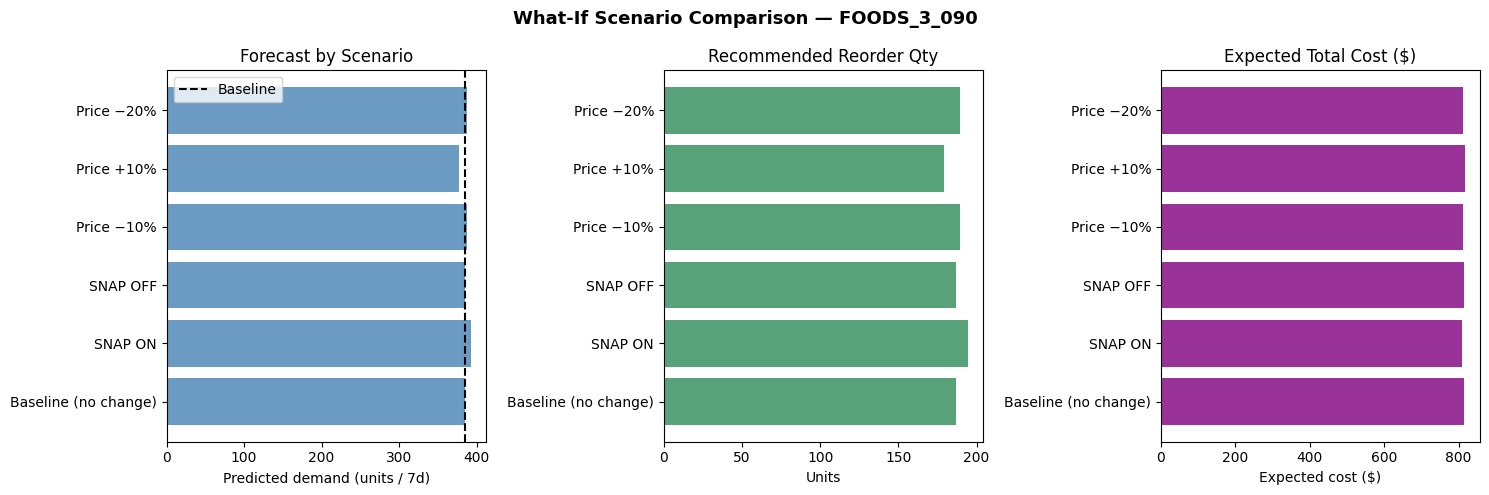

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['steelblue' if d >= 0 else 'tomato' for d in batch_df['delta']]

axes[0].barh(batch_df['label'], batch_df['scenario_pred'], color='steelblue', alpha=0.8)
axes[0].axvline(batch_df.loc[batch_df['label'] == 'Baseline (no change)', 'scenario_pred'].values[0],
                color='black', linestyle='--', linewidth=1.5, label='Baseline')
axes[0].set_title('Forecast by Scenario')
axes[0].set_xlabel('Predicted demand (units / 7d)')
axes[0].legend()

axes[1].barh(batch_df['label'], batch_df['reorder_qty'], color='seagreen', alpha=0.8)
axes[1].set_title('Recommended Reorder Qty')
axes[1].set_xlabel('Units')

axes[2].barh(batch_df['label'], batch_df['mean_total_cost'], color='purple', alpha=0.8)
axes[2].set_title('Expected Total Cost ($)')
axes[2].set_xlabel('Expected cost ($)')

plt.suptitle(f'What-If Scenario Comparison — {target_sku}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10) NLG Scenario Summary

In [24]:
# Use the most impactful scenario (largest absolute delta) for NLG
best_idx    = batch_df['delta'].abs().idxmax()
best_label  = batch_df.loc[best_idx, 'label']
best_overrides = {k: v for k, v in scenarios[best_idx].items() if k != 'label'}

result_best = simulate_scenario(
    model=model, X_row=X_sku, overrides=best_overrides,
    stock_on_hand=STOCK_ON_HAND, lead_time_days=LEAD_TIME,
    residual_std=sku_std_v, unit_margin=UNIT_MARGIN, holding_cost=HOLDING_COST,
)

text = generate_scenario_summary_text(result_best)
print(text)

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
=== What-If Scenario Summary ===
Changes applied: snap_relevant=1

Baseline forecast:  384.4 units
Scenario forecast:  392.1 units
Impact: +7.8 units (+2.0%)

Prediction interval (scenario):
  q10: 205.6  |  q50: 392.1  |  q90: 578.7

Replenishment recommendation:
  Safety stock: 186.5 units
  Recommended order qty: 194.3 units

Expected cost at recommended order qty:
  Mean stockout cost:  $808

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
